In [26]:

%pip install pyomo highspy

Note: you may need to restart the kernel to use updated packages.


RESTART KERNEL!

Zweite Energiemodelle und Analysen Hausübung

NAMEN MTRKLNR.

Ahmed Ahmedoski
Raphael Elser
Rainer Enders 
Sara Kapevska

Aufgabenstellung 10:

Gegenstand dieser Arbeit ist die mathematische Modellierung und Optimierung der Produktionsstrategie eines Wasserstoffelektrolyseurs. Im Fokus steht dabei eine binäre Entscheidungsfindung: Basierend auf den fluktuierenden Produktionskosten (insbesondere Strompreisen), den vertraglich fixierten Erlösen sowie potenziellen Strafzahlungen bei Nichtlieferung muss entschieden werden, ob der tägliche Wasserstoffbedarf vollständig gedeckt oder die Produktion gänzlich eingestellt wird. Da eine Teilversorgung explizit ausgeschlossen ist, wird ein wirtschaftlicher Abwägungsprozess modelliert, der den ökonomisch optimalen Betriebszustand unter Berücksichtigung dieser Parameter ermittelt.

## Mathematische Beschreibung
### 1. Indizes und Mengen
* $t \in T$: Index der Stunden im Betrachtungszeitraum (Tagesverlauf), wobei $T = \{0, 1, 2, \dots, 23\}$.

### 2. Modellparameter
* $C^{\text{prod}}_t$: Stündlicher Strompreis bzw. Produktionskosten in Stunde $t$ [$\text{€/MWh}$].
* $D$: Vertraglich festgelegter Wasserstoffgesamtbedarf des Tages [$\text{kg}$].
* $P^{\text{sell}}$: Fixer Verkaufserlös für Wasserstoff [$\text{€/kg}$].
* $P^{\text{penalty}}$: Einmalige Strafkosten (Pönale) bei Nichtdeckung des Bedarfs [$\text{€}$].
* $P_{\max}$: Maximale elektrische Leistung des Elektrolyseurs [$\text{MW}$].
* $\rho$: Spezifischer Energiebedarf (Energiedichte) zur Herstellung von Wasserstoff [$\text{MWh/kg}$].
* $\Delta t$: Zeitintervall [$\text{1 Stunde}$].

### 3. Entscheidungsvariablen
* $x \in \{0, 1\}$: Binäre Entscheidungsvariable ($x = 1$: Bedarf wird gedeckt; $x = 0$: Verzicht auf Produktion).
* $h_t \geq 0$: Kontinuierliche Produktionsmenge an Wasserstoff in Stunde $t$ [$\text{kg}$].

### 4. Zielfunktion
Das Ziel ist die Minimierung der ökonomischen Gesamtkosten über den gesamten Tag:

$$ \min \, Z = \sum_{t \in T} \left( C^{\text{prod}}_t \cdot \rho \cdot h_t \right) + (1 - x) \cdot P^{\text{penalty}} - x \cdot (P^{\text{sell}} \cdot D) $$

### 5. Nebenbedingungen

**Vollständige Deckung oder gänzlicher Verzicht (Bedarfsnebenbedingung):**
Die Summe der stündlichen Produktionsmengen muss exakt dem Tagesbedarf entsprechen, wenn produziert wird:
$$ \sum_{t \in T} h_t = x \cdot D $$

**Maximale stündliche Produktionskapazität (Anlagenbegrenzung):**
Die stündliche Wasserstoffproduktion ist durch die maximale elektrische Leistung des Elektrolyseurs begrenzt:
$$ h_t \leq x \cdot \left( \frac{P_{\max}}{\rho} \right) \cdot \Delta t \quad \forall t \in T $$

**Nichtnegativität und Binärbedingungen:**
$$ h_t \geq 0 \quad \forall t \in T $$
$$ x \in \{0, 1\} $$


## Qualitative Beschreibung der Modellierung und Vorgehensweise

#### Modellierungsansatz
Das vorliegende Problem ist ein **gemischt-ganzzahliges lineares Optimierungsproblem (MILP)**. Die Kernherausforderung liegt in der "Alles-oder-nichts"-Entscheidung (binäre Struktur): Es ist regulatorisch oder vertraglich nicht zulässig, den Wasserstoffbedarf nur teilweise zu decken. Daher steuert eine binäre Entscheidungsvariable ($x$), ob das System in den Produktionsmodus wechselt oder am aktuellen Tag vollständig ruht.

#### Ökonomische Abwägung (Trade-off)
Das Optimierungsmodell wägt kontinuierlich zwischen drei finanziellen Strömen ab:
1. **Stromkosten (Produktion):** Diese fallen stündlich an und hängen direkt von den volatilen Day-Ahead-Strompreisen ab. Da die Strompreise über den Tag stark schwanken, versucht das Modell bei aktivierter Produktion ($x=1$), die Erzeugung in die günstigsten Stunden (z.B. Nachtstunden oder Mittagsspitzen bei hoher PV-Einspeisung) zu verschieben.
2. **Erlöse (Verkauf):** Bei erfolgreicher Deckung des Gesamtbedarfs wird ein fixer, exogen vorgegebener Wasserstoffpreis erlöst.
3. **Strafkosten (Pönale):** Wird die Produktion aufgrund zu hoher Strompreise gänzlich eingestellt ($x=0$), entfallen zwar die variablen Produktionskosten und Erlöse, es wird jedoch sofort eine fixe Strafzahlung fällig.

#### Technische Restriktionen und Vorgehensweise
Um das reale Verhalten des Wasserstoffelektrolyseurs abzubilden, ist die stündliche Produktionsmenge durch die maximale elektrische Anschlussleistung der Anlage ($P_{\max}$) limitiert. Über den Parameter der Energiedichte ($\rho$) wird die elektrische Leistung in die maximal mögliche stündliche Wasserstoff-Ausbringungsmenge in Kilogramm umgerechnet. 

Durch die Kopplung der Kapazitäts- und Bedarfsbedingungen an die Binärvariable $x$ wird mathematisch sichergestellt, dass bei einem Verzicht auf die Produktion ($x=0$) auch die stündlichen Produktionsvariablen ($h_t$) für den gesamten Tag zwingend auf Null gesetzt werden. Das Modell findet somit automatisiert den global kostenoptimalen (bzw. gewinnmaximalen) Fahrplan für den Anlagenbetreiber.


## Pythoncode

In [27]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np

# 1. Daten generieren (Beispielwerte)
hours = range(24)                                                                       #Stündliche Auflösung
Electricity_prices = [20, 15, 10, 12, 18, 30, 50, 80, 100, 90, 70, 60, 
          55, 65, 85, 120, 150, 140, 90, 60, 40, 30, 25, 20]                            # Strompreise in €/MWh

model = pyo.ConcreteModel()                                                             # Erstellen eines konkreten Modells

# Sets & Parameter
model.Time = pyo.Set(initialize=hours)                                                  #Zeit in Stunden

#Produktionskosten in €/MWh
model.Hydro_Productionscost = pyo.Param(model.Time, initialize=dict(enumerate(Electricity_prices)))  

model.Hydro_Demand = pyo.Param(initialize=500)                                          # Bedarf in kg
model.Hydro_Sellingprice = pyo.Param(initialize=15.0)                                   # Verkaufspreis in € pro aufgewandter MWh
model.Penaltycosts = pyo.Param(initialize=2000.0)                                       # Strafkosten bei Nichtdeckung in €
model.P_max = pyo.Param(initialize=2.0)                                                 # Leistung in MW
model.Energydensity = pyo.Param(initialize=0.05)                                        # Energiedichte in MWh/kg (ca. 50 kWh/kg)

# Variablen
model.x = pyo.Var(domain=pyo.Binary)                                                    #Entscheidungsvariable zur Produktion (1) oder Nichtproduktion (0)
model.h = pyo.Var(model.Time, domain=pyo.NonNegativeReals)                              #Produktionsmenge kann nicht negativ sein

# Zielfunktion
def obj_rule(m):
    revenue = m.x * (m.Hydro_Sellingprice * m.Hydro_Demand)                             #Einnahmen bei vollständiger Deckung des Bedarfs
    costs = sum(m.Hydro_Productionscost[t] * m.Energydensity * m.h[t] for t in m.Time)  #Variable Stromkosten der Produktion
    penalty = (1 - m.x) * m.Penaltycosts                                                #Strafkosten, wenn nicht produziert wird (Nichtdeckung des Bedarfs)   
    return revenue - costs - penalty                                                    #Gesamtgewinn = Einnahmen - Kosten - Strafkosten
model.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)                            #Maximierung Gewinn

# Nebenbedingungen (Constraints)
def demand_rule(m):
    return sum(m.h[t] for t in m.Time) == m.x * m.Hydro_Demand                          # Bedarfsdeckung: x=1, Summe der Produktion = Bedarf; x=0,=> Produktion 0
model.demand_constraint = pyo.Constraint(rule=demand_rule)                              # Bedarfsdeckung sicherstellen    

def capacity_rule(m, t):
    return m.h[t] <= m.x * (m.P_max / m.Energydensity)                                  # Maximale Produktionsmenge pro Stunde darf die Kapazität nicht überschreiten (umgerechnet in kg)
model.capacity_constraint = pyo.Constraint(model.Time, rule=capacity_rule)              # Maximale Leistung darf nicht überschritten werden


# Solver aufrufen (z.B. glpk oder cbc)
solver = pyo.SolverFactory('appsi_highs')                                               # Solver für lineare & gemischt-ganzzahlige Probleme                   
results = solver.solve(model)                                                           # Optimierung/Lösung des Modells

# Ergebnisse ausgeben
print(f"Produktionsentscheidung (x): {pyo.value(model.x)}")                             # 1 = Produktion, 0 = keine Produktion
print(f"Gesamtgewinn: {pyo.value(model.obj)} €")                                        # Gesamtgewinn in €


Produktionsentscheidung (x): 1.0
Gesamtgewinn: 6790.0 €


## Grafiken

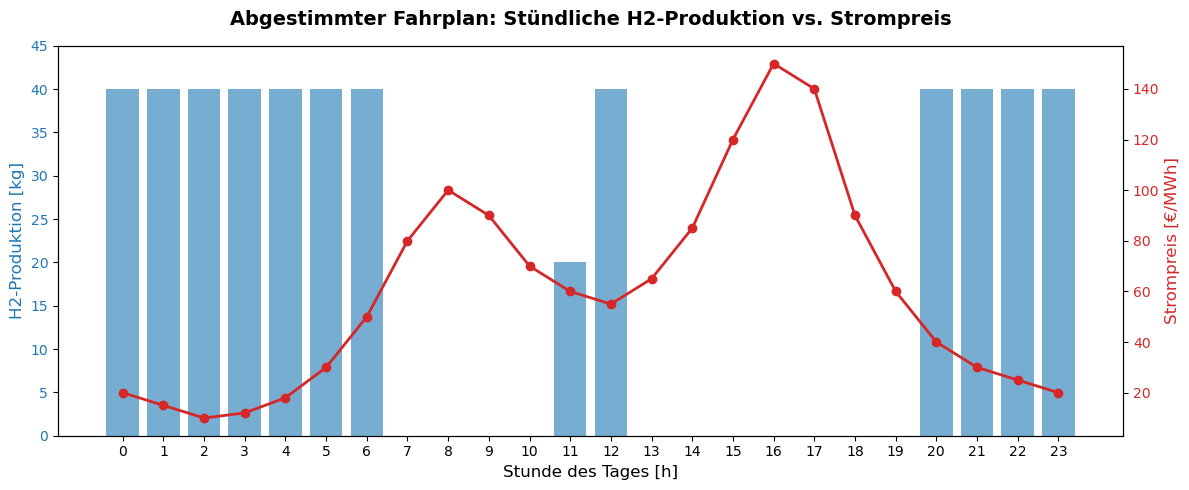

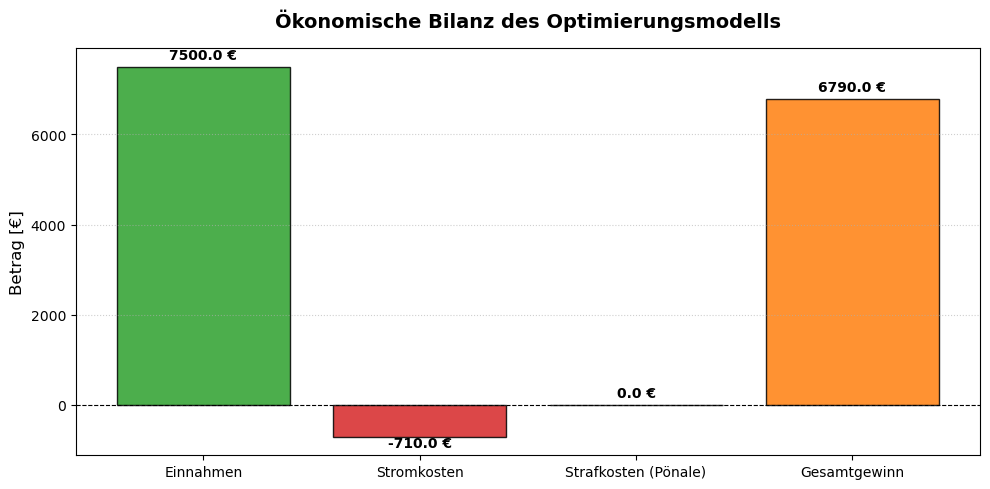

In [28]:
import matplotlib.pyplot as plt

# 1. Daten aus dem gelösten Pyomo-Modell extrahieren
production_hours = list(model.Time)
production_values = [pyo.value(model.h[t]) for t in model.Time]
prices = [pyo.value(model.Hydro_Productionscost[t]) for t in model.Time]

# Berechnungen für die ökonomische Bilanz
x_val = pyo.value(model.x)
total_revenue = x_val * (pyo.value(model.Hydro_Sellingprice) * pyo.value(model.Hydro_Demand))
total_costs = sum(prices[t] * pyo.value(model.Energydensity) * production_values[t] for t in production_hours)
total_penalty = (1 - x_val) * pyo.value(model.Penaltycosts)
total_profit = pyo.value(model.obj)

# ==============================================================================
# GRAFIK 1: Stündlicher Fahrplan des Elektrolyseurs vs. Strompreis (Dual-Axis)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(12, 5))

# Balkendiagramm für die Wasserstoffproduktion
color = '#1f77b4'
ax1.set_xlabel('Stunde des Tages [h]', fontsize=12)
ax1.set_ylabel('H2-Produktion [kg]', color=color, fontsize=12)
bars = ax1.bar(production_hours, production_values, color=color, alpha=0.6, label='H2-Produktion (kg)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 45)
ax1.set_xticks(production_hours)

# Zweite Achse für den Strompreis
ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Strompreis [€/MWh]', color=color, fontsize=12)
line = ax2.plot(production_hours, prices, color=color, marker='o', linewidth=2, label='Strompreis (€/MWh)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Abgestimmter Fahrplan: Stündliche H2-Produktion vs. Strompreis', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# ==============================================================================
# GRAFIK 2: Ökonomische Bilanz der Produktionsentscheidung
# ==============================================================================
categories = ['Einnahmen', 'Stromkosten', 'Strafkosten (Pönale)', 'Gesamtgewinn']
financial_values = [total_revenue, -total_costs, -total_penalty, total_profit]
colors = ['#2ca02c', '#d62728', '#7f7f7f', '#ff7f0e']

plt.figsize=(10, 5)
plt.figure(figsize=(10, 5))
bars_fin = plt.bar(categories, financial_values, color=colors, alpha=0.85, edgecolor='black')

# Werte über den Balken anzeigen
for bar in bars_fin:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (100 if yval >= 0 else -300), f"{round(yval, 2)} €", ha='center', va='bottom', fontweight='bold')

plt.ylabel('Betrag [€]', fontsize=12)
plt.title('Ökonomische Bilanz des Optimierungsmodells', fontsize=14, fontweight='bold', pad=15)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
